In [1]:
%load_ext autoreload
%autoreload 2

import pygtfcode as gtf
from pprint import pprint

# Frank core-in-core example

In [2]:
config = gtf.Config()
config.init = ('truncated_NFW', {'Zt': 0.00807, 'deltaP': 1.0e-5, 'Mvir': 1.0e12, 'cvir': 30})

config.sim.sigma_m = 250
config.sim.c = 0.88
config.sim.t_halt = 1.0e6
config.sim.rho_c_halt = 1.0e6

config.prec.eps_dt = 1.0e-1
config.prec.eps_du = 1.0e-3

config.grid.rmin = 0.01
config.grid.rmax = 1000
config.grid.ngrid = 300

config.io.nupdate = 3500
config.io.model_no = 102 # Testing

In [3]:
state = gtf.State.from_config(config)

Computing characteristic parameters for simulation...
Generating lookup for rho(phi)...
Computing potential profile for truncated NFW halo...
Integrating Poisson equation outward: r = 1172.651400, phi = -0.000000
Setting up radial grid...
Initializing profiles...
Computing Menc: r = 428.654, m = 4.738

/Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/pygtfcode/profiles/truncated_nfw.py:274: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  val, _ = quad(


Computing Menc: r = 1000.000, m = 4.933
Generating lookup for v2 integrand...
Computing v2: r = 981.114, v2 = 0.000
Ensuring initial hydrostatic equilibrium...
	Initial pressure correction applied. HE residual improved 1.380e+00 -> 2.704e-14.
Hydrostatic equilibrium achieved in 5 iterations. Max |dr/r| = 2.63e-16.  HE res 1.0025015799855264.
State initialized.
Directory already exists: /Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments/Model102
Model information written to model_metadata.txt
Initial profiles written to disk.


In [4]:
state.run()

Initial profiles written to disk.
Time evolution file initialized.
Log file initialized:
      step          time          <dt>         rho_c         v_max        Kn_min  <dt lim>  <du lim>  <dr lim>  <n_iter_du>  <n_iter_dr>
         0  0.000000e+00           N/A  1.303894e+02  3.068619e-01  2.057816e-02       N/A       N/A       N/A          N/A          N/A
    100000  6.033420e+04  6.033420e-01  5.038078e+05  1.351116e+00  2.594852e-05  4.33e+05  8.38e-01  2.39e-03  8.02810e-01  2.00000e+00
Simulation halted: central density exceeds halting value
    110656  6.554306e+04  4.888196e-01  1.000056e+06  1.424825e+00  1.746481e-05  4.96e+06  9.50e-01  2.14e-03  1.00000e+00  2.00000e+00
Total time for run(): 7.92s


In [6]:
state.make_movie(profiles=['rho', 'v2', 'kn'])

Generating 161 frames...


Frames: 100%|██████████| 161/161 [01:14<00:00,  2.15frame/s]


Compiling into a movie using ffmpeg...
Deleting frames...
Movie saved to /Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments/Model102/movie_rho_v2_kn.mp4


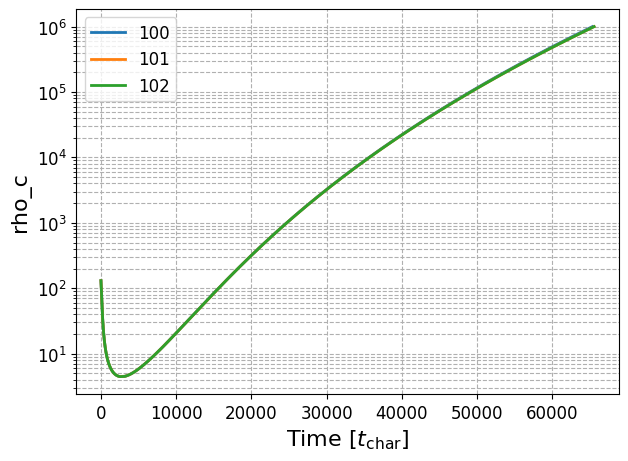

In [5]:
gtf.plot_time_evolution([100, 101, 102], base_dir='/Users/yaronetokayer/YaleDrive/Research/SIDM/pygtfcode/experiments', grid=True)